In [8]:
# 고전 컴퓨터비전(Classical CV) 실습 — Canny 엣지 검출(Edge Detection)
#
# Canny 알고리즘의 핵심 파이프라인을 "도메인 → 유스케이스 → 인프라(cv2 어댑터) →
# 구성 루트(Colab 실행 코드)"의 4개 계층으로 분리해 구현한다. 각 계층은 주석
# 배너로 명확히 구분하며, 아래 방향으로만 의존한다(구성 루트 → 인프라 → 유스케이스
# → 도메인). cv2는 인프라 계층에서만 import한다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체(dataclass) + 추상 인터페이스(abc.ABC). cv2 비의존.
#   [유스케이스 계층]   — EdgeDetectionUseCase. 인터페이스만 주입받아 흐름을 조립.
#   [인프라 계층]      — cv2 기반 실제 구현체(전처리/엣지검출/시각화를 분리).
#   [구성 루트]        — Colab 셀: 이미지 로드, DI 조립, matplotlib 시각화/저장.

## 셀 1: 환경 준비

In [18]:
!pip install opencv-python-headless scikit-image matplotlib numpy --quiet
# (한글 폰트가 없는 환경이면)
!apt-get -qq install -y fonts-nanum && fc-cache -f
import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
for _font_path in _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"):
    _font_manager.fontManager.addfont(_font_path)  # 폰트 매니저에 명시적으로 등록
matplotlib.rcParams["font.family"] = "NanumGothic"  # 그래프 한글 깨짐 방지
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====
# cv2를 전혀 모르는 순수 파이썬 계층. "엣지 검출이란 무엇을 입력받아 무엇을
# 돌려주는가"라는 규칙(계약)만 정의한다.
from abc import ABC, abstractmethod
from dataclasses import dataclass

@dataclass(frozen=True)
class EdgeDetectionResult:
    """엣지 검출 결과 값 객체. 입력/중간/최종 산출물을 한데 묶어 유스케이스가
    인프라의 내부 구현(어떤 변수를 썼는지 등)을 몰라도 되게 한다."""
    original_rgb: np.ndarray       # 시각화용 원본(RGB)
    blurred_gray: np.ndarray       # 전처리(블러) 후 그레이스케일
    gradient_magnitude: np.ndarray  # 소벨 그래디언트 크기(설명용 중간 산출물)
    edges: np.ndarray              # 최종 Canny 엣지 맵(0/255 이진 이미지)
    low_threshold: float
    high_threshold: float

class ImagePreprocessor(ABC):
    """전처리(잡음 제거) 책임만 갖는 작은 인터페이스 (ISP)."""

    @abstractmethod
    def to_blurred_gray(self, bgr_image: np.ndarray) -> np.ndarray:
        ...

class EdgeDetector(ABC):
    """엣지 검출 책임만 갖는 인터페이스. 구현을 Canny가 아닌 다른 알고리즘으로
    바꿔도(OCP) 유스케이스 코드는 전혀 수정할 필요가 없다."""

    @abstractmethod
    def detect(self, blurred_gray: np.ndarray) -> EdgeDetectionResult:
        ...
# ===== [유스케이스 계층 / Use Case Layer] =====
# 도메인 인터페이스만 생성자로 주입받아(DIP) 실행 순서를 조립한다. cv2를
# 직접 호출하지 않으므로, 이 클래스만 보고도 "무엇을 하는지"가 드러난다.
class EdgeDetectionUseCase:
    def __init__(self, preprocessor: ImagePreprocessor, detector: EdgeDetector):
        self._preprocessor = preprocessor
        self._detector = detector

    def run(self, bgr_image: np.ndarray) -> EdgeDetectionResult:
        blurred_gray = self._preprocessor.to_blurred_gray(bgr_image)
        return self._detector.detect(blurred_gray)
# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====
# cv2를 실제로 호출하는 유일한 계층. "계산(전처리/검출)"과 "시각화"를 서로
# 다른 클래스로 분리해(SRP) 어느 하나를 바꿔도 다른 하나는 영향받지 않게 한다.

import cv2

class GaussianBlurPreprocessor(ImagePreprocessor):
    """가우시안 블러로 잡음을 줄인 뒤 그레이스케일로 변환하는 cv2 어댑터."""

    def __init__(self, ksize: int = 5, sigma: float = 1.4):
        self._ksize = ksize
        self._sigma = sigma

    def to_blurred_gray(self, bgr_image: np.ndarray) -> np.ndarray:
        gray = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)
        return cv2.GaussianBlur(gray, (self._ksize, self._ksize), self._sigma)

class CannyEdgeDetector(EdgeDetector):
    """Canny 알고리즘 cv2 어댑터. 소벨 그래디언트는 설명용으로 별도 계산한다
    (비최대 억제/이력 임계값 자체는 cv2.Canny 내부에서 수행됨)."""

    def __init__(self, low_threshold: float = 50, high_threshold: float = 150):
        self._low = low_threshold
        self._high = high_threshold
        self._original_rgb_holder: np.ndarray | None = None  # run()에서 주입

    def attach_original(self, original_rgb: np.ndarray) -> "CannyEdgeDetector":
        """원본(RGB)을 결과 객체에 함께 담기 위한 간단한 주입 메서드."""
        self._original_rgb_holder = original_rgb
        return self

    def detect(self, blurred_gray: np.ndarray) -> EdgeDetectionResult:
        # 1) 그래디언트(밝기 변화율) 계산 — 설명용 중간 산출물
        sobel_x = cv2.Sobel(blurred_gray, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(blurred_gray, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = cv2.magnitude(sobel_x, sobel_y)

        # 2) 비최대 억제 + 2단계(상/하) 임계값으로 진짜 경계선만 선별
        edges = cv2.Canny(blurred_gray, self._low, self._high)

        assert self._original_rgb_holder is not None, "attach_original()을 먼저 호출하세요"
        return EdgeDetectionResult(
            original_rgb=self._original_rgb_holder,
            blurred_gray=blurred_gray,
            gradient_magnitude=gradient_magnitude,
            edges=edges,
            low_threshold=self._low,
            high_threshold=self._high,
        )

class EdgeDetectionVisualizer:
    """결과 시각화 전담 클래스(계산 로직과 분리 — SRP). matplotlib로 2x2 비교
    그림을 그리고 파일로 저장한다. 도메인/유스케이스는 이 클래스의 존재조차 모른다."""

    def __init__(self, title: str):
        self._title = title

    def save_comparison(self, result: EdgeDetectionResult, out_path: str) -> None:
        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(self._title, fontsize=14, fontweight="bold")

        axes[0].imshow(result.original_rgb)
        axes[0].set_title("1. 원본")
        axes[1].imshow(result.blurred_gray, cmap="gray")
        axes[1].set_title("2. 블러 + 그레이스케일")
        axes[2].imshow(result.gradient_magnitude, cmap="gray")
        axes[2].set_title("3. 그래디언트 크기 (Sobel)")
        axes[3].imshow(result.edges, cmap="gray")
        axes[3].set_title(f"4. Canny 엣지 (th={result.low_threshold:.0f}/{result.high_threshold:.0f})")

        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"저장 완료: {out_path}")
# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====
# 여기서만 파일 I/O, 구체 클래스 생성, 의존성 주입(DI)이 일어난다.

## 셀 2: 테스트 이미지 준비 (scikit-image 내장 샘플 — 다운로드 불필요)

In [19]:
from skimage import data as skdata

astronaut_rgb = skdata.astronaut()                       # RGB, uint8
astronaut_bgr = cv2.cvtColor(astronaut_rgb, cv2.COLOR_RGB2BGR)
print("입력 이미지 크기:", astronaut_bgr.shape)

입력 이미지 크기: (512, 512, 3)


## 셀 3: 구체 어댑터 생성 + 의존성 주입(DIP) — 유스케이스는 추상 타입만 안다

In [21]:
preprocessor: ImagePreprocessor = GaussianBlurPreprocessor(ksize=5, sigma=1.4)
detector: EdgeDetector = CannyEdgeDetector(low_threshold=50, high_threshold=150)
detector.attach_original(astronaut_rgb)  # 시각화용 원본 주입

use_case = EdgeDetectionUseCase(preprocessor=preprocessor, detector=detector)

## 셀 4: 실행

In [22]:
result = use_case.run(astronaut_bgr)
print("엣지 픽셀 수:", int(np.count_nonzero(result.edges)))

엣지 픽셀 수: 16211


## 셀 5: 결과 시각화 및 저장

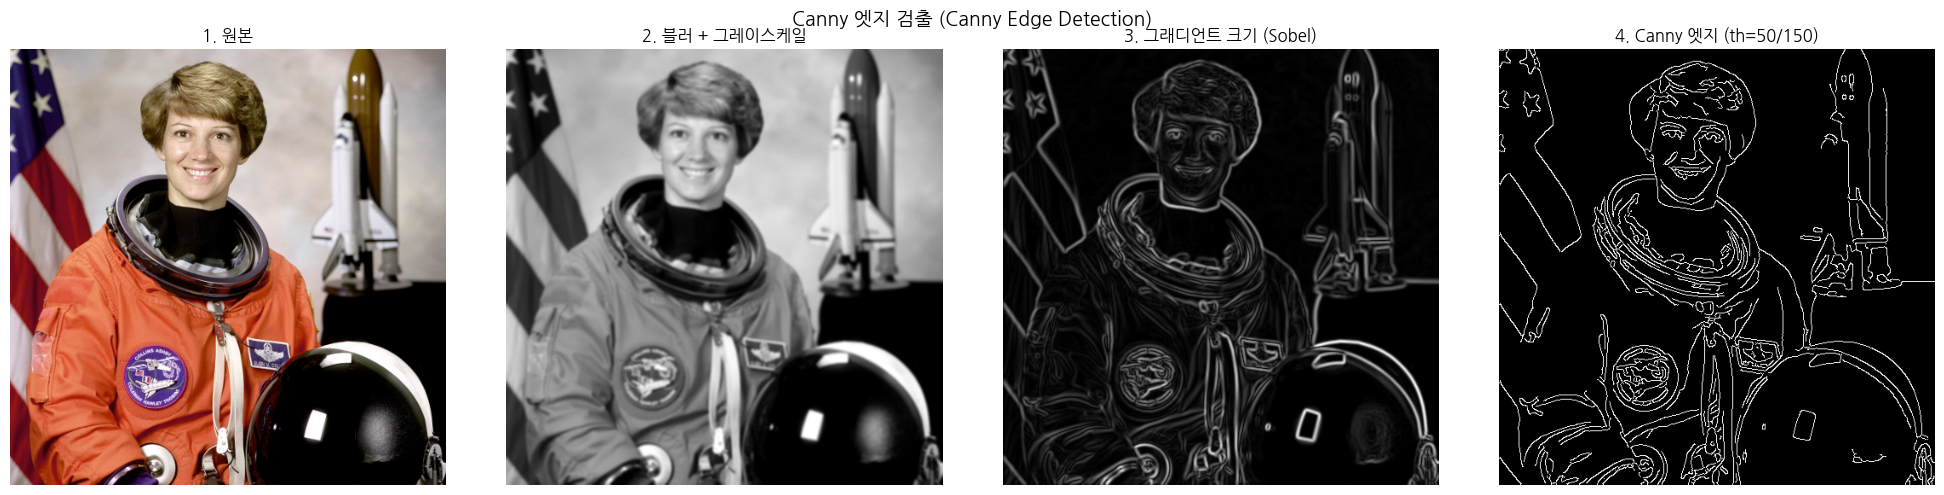

저장 완료: canny_edge_result.png


In [23]:
visualizer = EdgeDetectionVisualizer(title="Canny 엣지 검출 (Canny Edge Detection)")
visualizer.save_comparison(result, "canny_edge_result.png")

## 셀 6: (선택) 임계값을 바꿔가며 비교 — OCP 확인용

In [24]:
# CannyEdgeDetector는 새 임계값으로 "새 인스턴스"를 만들기만 하면 되고,
# EdgeDetectionUseCase/도메인 계층은 한 줄도 수정하지 않는다.
for low, high in [(30, 90), (50, 150), (100, 200)]:
    d = CannyEdgeDetector(low_threshold=low, high_threshold=high).attach_original(astronaut_rgb)
    r = EdgeDetectionUseCase(preprocessor, d).run(astronaut_bgr)
    print(f"low={low:>3}, high={high:>3} -> 엣지 픽셀 수 {int(np.count_nonzero(r.edges))}")

low= 30, high= 90 -> 엣지 픽셀 수 21280
low= 50, high=150 -> 엣지 픽셀 수 16211
low=100, high=200 -> 엣지 픽셀 수 12114
